In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
import pickle

In [ ]:
df = pd.read_csv('loan_data.csv')
print(df.shape)
df.head()

(9578, 14)


,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [ ]:
df.isnull().sum()

,0
credit.policy,0
purpose,0
int.rate,0
installment,0
log.annual.inc,0
dti,0
fico,0
days.with.cr.line,0
revol.bal,0
revol.util,0


<Axes: >

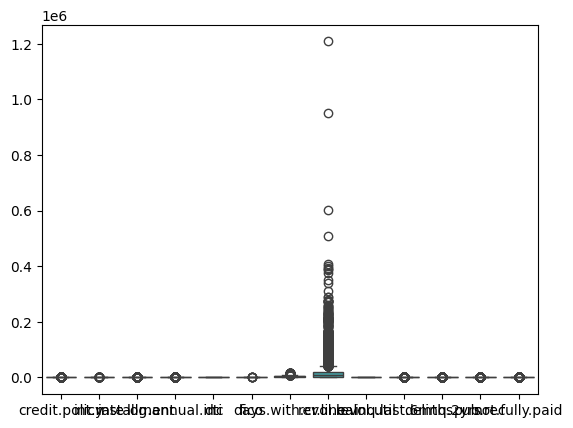

In [ ]:
sns.boxplot(df)

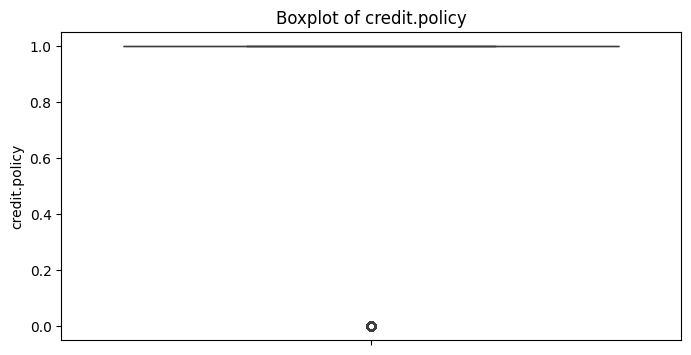

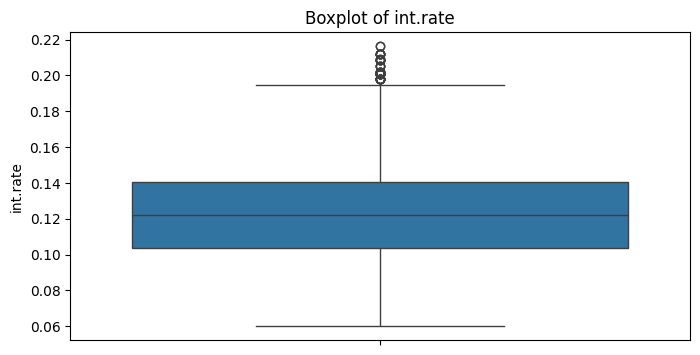

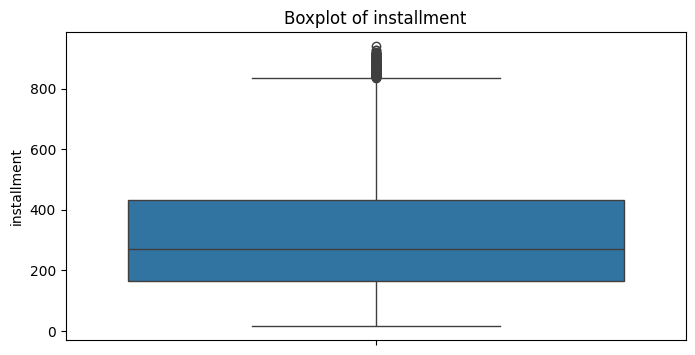

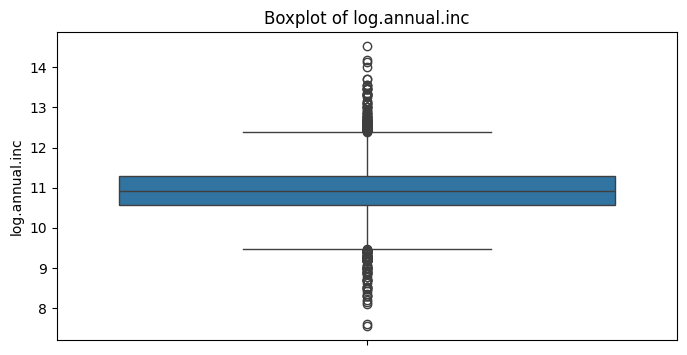

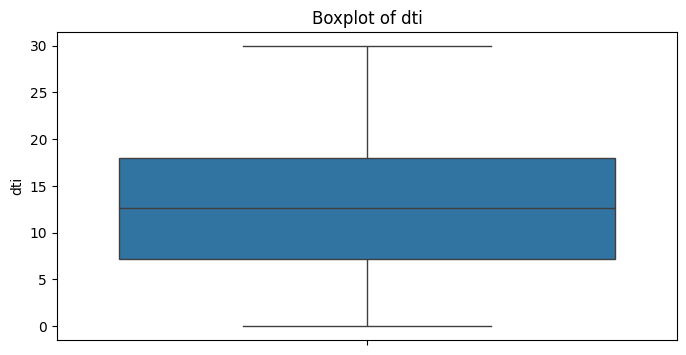

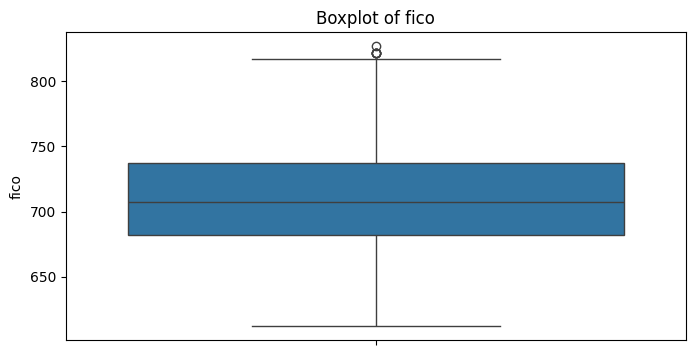

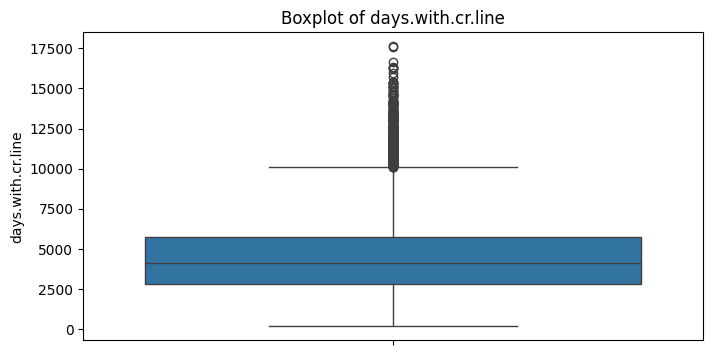

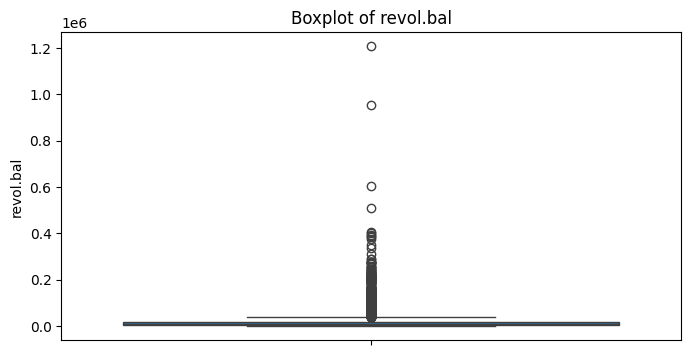

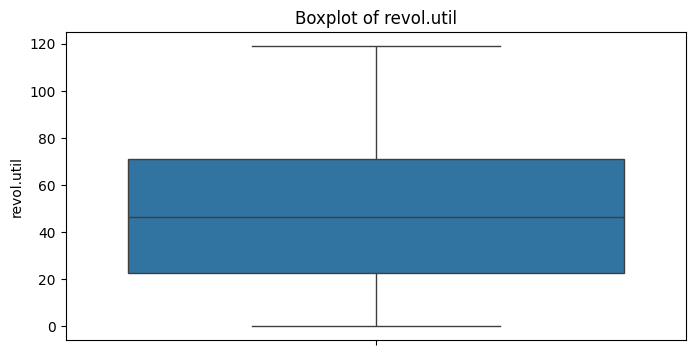

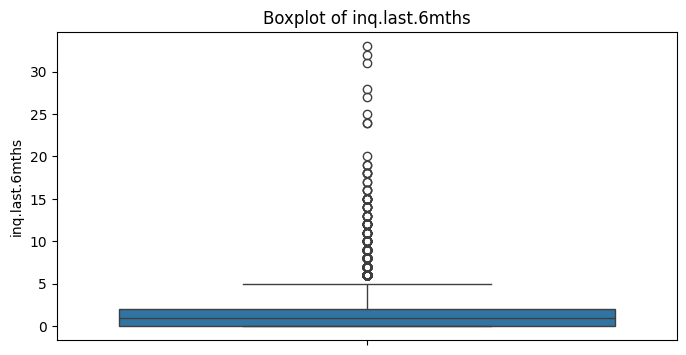

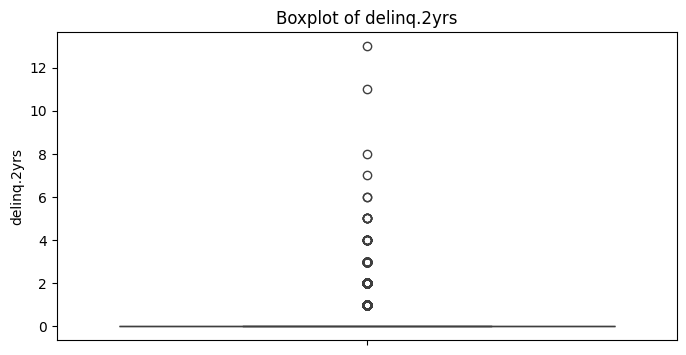

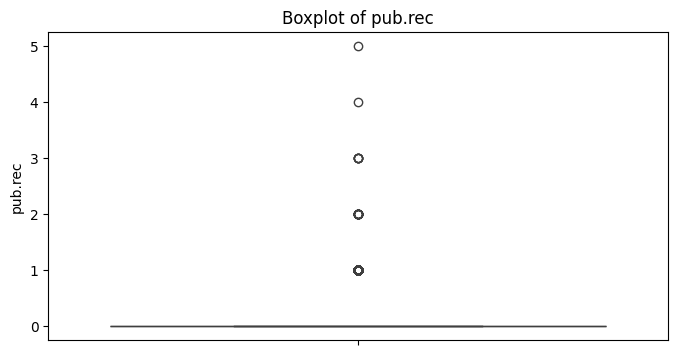

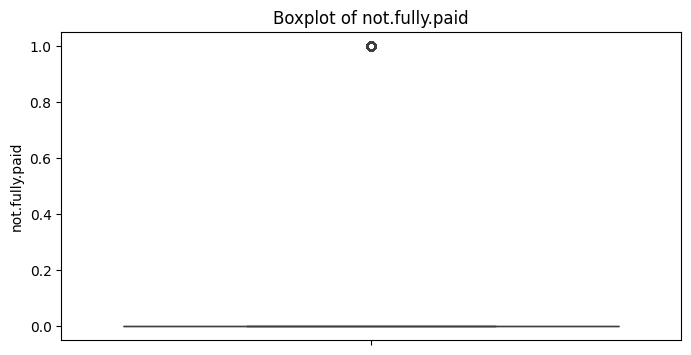

In [ ]:
# Select only numerical columns for boxplots
numerical_cols = df.select_dtypes(include=np.number).columns

# Iterate through numerical columns and create boxplots
for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

Shape before cleaning: (9578, 14)

Preview:
   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec 

/tmp/ipython-input-1497554587.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Feature', y='Value', data=df_melt, palette='Set2')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


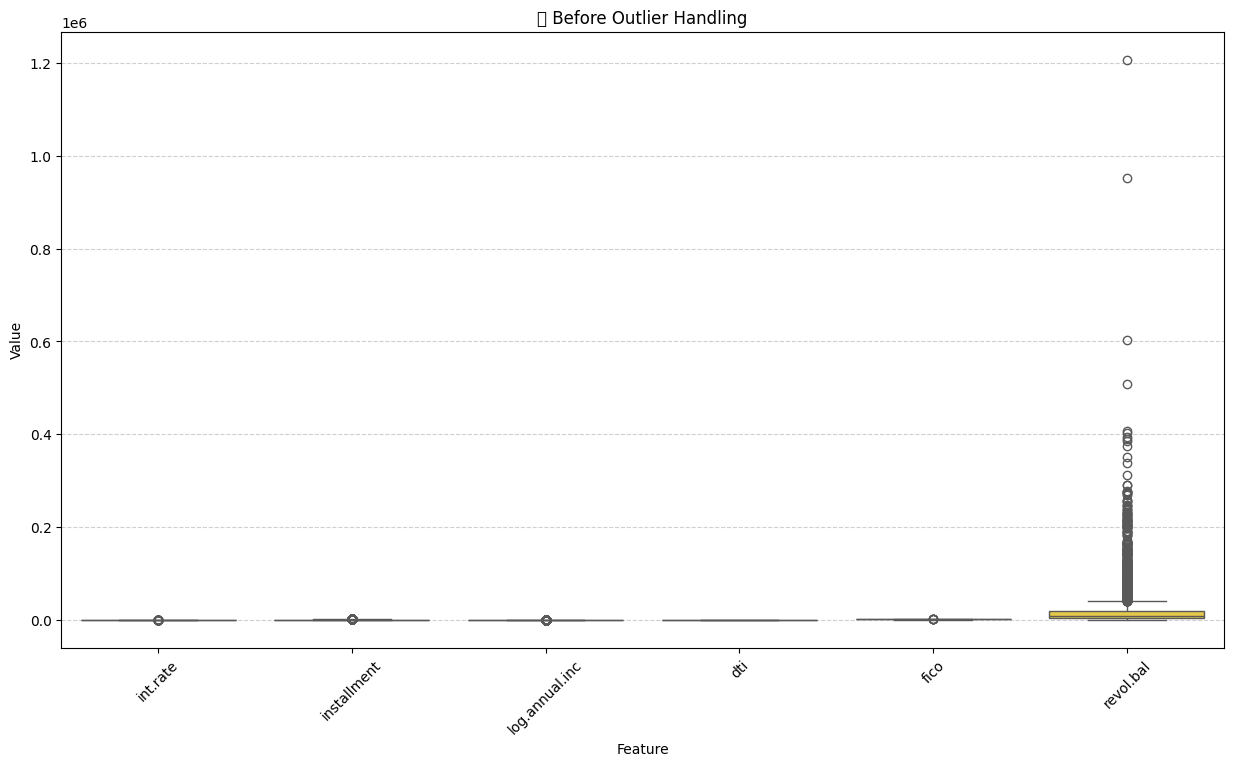


✅ Outliers capped using IQR method.


/tmp/ipython-input-1497554587.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Feature', y='Value', data=df_melt_after, palette='coolwarm')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


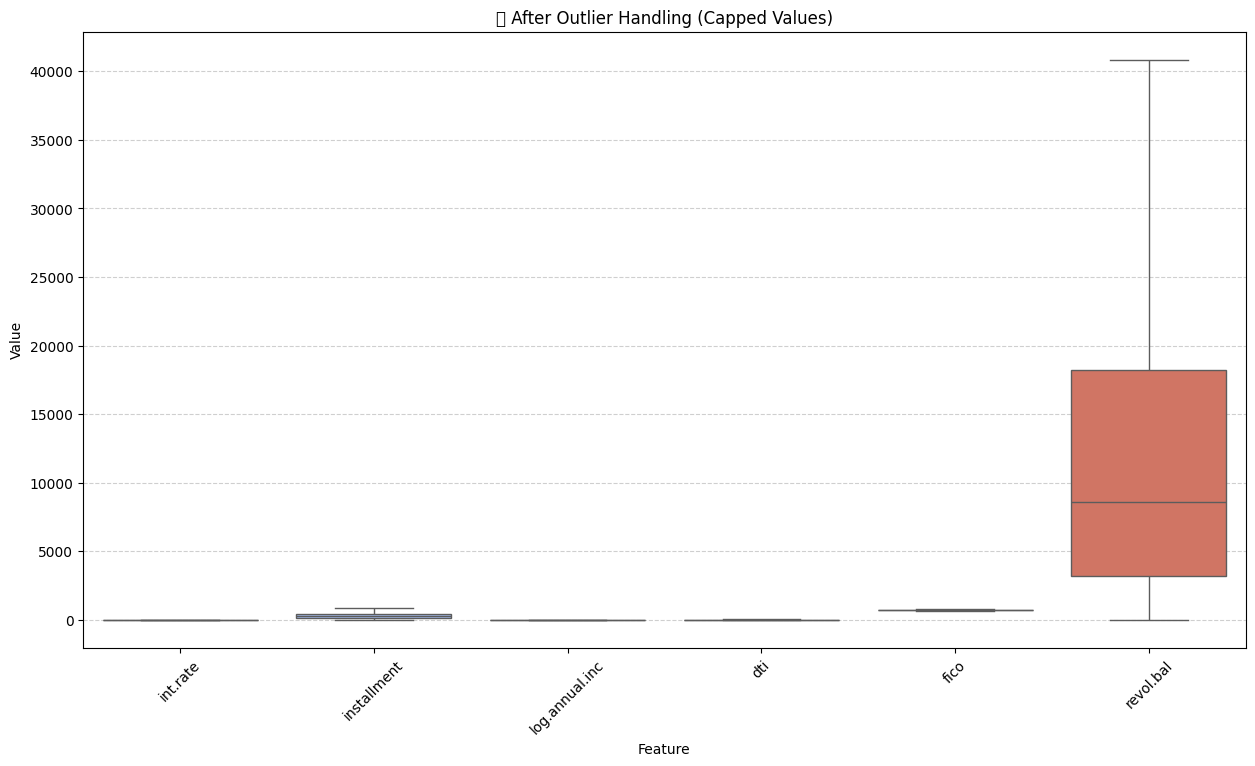


💾 Cleaned dataset saved as 'loan_data_cleaned.csv'
Shape after cleaning: (9578, 14)


In [ ]:
# 📦 IMPORTS
# ============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ============================
# 🧾 LOAD DATASET
# ============================

print(f"Shape before cleaning: {df.shape}")
print("\nPreview:")
print(df.head())

# ============================
# 📊 VISUALIZE BEFORE OUTLIER HANDLING
# ============================
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Exclude target column if you want
if 'credit.policy' in numeric_cols:
    numeric_cols.remove('credit.policy')

# Pick a few important numeric columns to visualize
cols_to_plot = ['int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'revol.bal']

# Filter only columns that exist in your dataset
cols_to_plot = [col for col in cols_to_plot if col in df.columns]

print(f"\nBoxplots before outlier handling for: {cols_to_plot}")

plt.figure(figsize=(15, 8))
df_melt = df[cols_to_plot].melt(var_name='Feature', value_name='Value')
sns.boxplot(x='Feature', y='Value', data=df_melt, palette='Set2')
plt.title("📦 Before Outlier Handling")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ============================
# ⚙️ OUTLIER HANDLING (IQR METHOD)
# ============================
df_cleaned = df.copy()

for col in numeric_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap outliers
    df_cleaned[col] = np.where(df_cleaned[col] < lower_bound, lower_bound,
                               np.where(df_cleaned[col] > upper_bound, upper_bound, df_cleaned[col]))

print("\n✅ Outliers capped using IQR method.")

# ============================
# 📊 VISUALIZE AFTER OUTLIER HANDLING
# ============================
plt.figure(figsize=(15, 8))
df_melt_after = df_cleaned[cols_to_plot].melt(var_name='Feature', value_name='Value')
sns.boxplot(x='Feature', y='Value', data=df_melt_after, palette='coolwarm')
plt.title("✅ After Outlier Handling (Capped Values)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# ============================
# 💾 SAVE CLEANED DATA
# ============================
df_cleaned.to_csv("loan_data_cleaned.csv", index=False)
print("\n💾 Cleaned dataset saved as 'loan_data_cleaned.csv'")
print(f"Shape after cleaning: {df_cleaned.shape}")

In [ ]:
cols=df[['int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']]
from sklearn.preprocessing import MinMaxScaler
scalar=MinMaxScaler()
num_scaled=scalar.fit_transform(cols)
num_scaled[:5]
num_scaled_df=pd.DataFrame(num_scaled,columns=cols.columns)
num_scaled_df.head()

,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,0.376598,0.879888,0.544762,0.650200,0.581395,0.312754,0.023898,0.437815,0.000000,0.000000,0.0,0.0
1,0.301151,0.229916,0.506334,0.476969,0.441860,0.147818,0.027848,0.644538,0.000000,0.000000,0.0,0.0
2,0.484015,0.379883,0.404820,0.388184,0.325581,0.259495,0.002908,0.215126,0.030303,0.000000,0.0,0.0
3,0.260870,0.158653,0.544762,0.270360,0.465116,0.144379,0.027885,0.615126,0.030303,0.000000,0.0,0.0
4,0.528133,0.094378,0.537503,0.499666,0.255814,0.222613,0.003926,0.331933,0.000000,0.076923,0.0,0.0


In [ ]:
c1=df.drop(cols,axis=1)

In [ ]:
final_df=pd.concat([num_scaled_df,c1],axis=1)
final_df.head()

,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,credit.policy,purpose
0,0.376598,0.879888,0.544762,0.650200,0.581395,0.312754,0.023898,0.437815,0.000000,0.000000,0.0,0.0,1,2
1,0.301151,0.229916,0.506334,0.476969,0.441860,0.147818,0.027848,0.644538,0.000000,0.000000,0.0,0.0,1,1
2,0.484015,0.379883,0.404820,0.388184,0.325581,0.259495,0.002908,0.215126,0.030303,0.000000,0.0,0.0,1,2
3,0.260870,0.158653,0.544762,0.270360,0.465116,0.144379,0.027885,0.615126,0.030303,0.000000,0.0,0.0,1,2
4,0.528133,0.094378,0.537503,0.499666,0.255814,0.222613,0.003926,0.331933,0.000000,0.076923,0.0,0.0,1,1


In [ ]:
selected_features = [
    'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
    'days.with.cr.line', 'revol.bal', 'revol.util', 'inq.last.6mths',
    'delinq.2yrs', 'pub.rec', 'purpose'
]

X = df[selected_features].copy() # Create a copy to avoid SettingWithCopyWarning
y = df['not.fully.paid']

# Apply LabelEncoder to the 'purpose' column in X
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X['purpose'] = le.fit_transform(X['purpose'])

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["purpose"]=le.fit_transform(df["purpose"])
df

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,2,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,1,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,2,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,2,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,1,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,0,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,0,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,2,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,4,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1


In [ ]:
final_df

,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,credit.policy,purpose
0,0.376598,0.879888,0.544762,0.650200,0.581395,0.312754,0.023898,0.437815,0.000000,0.000000,0.0,0.0,1,2
1,0.301151,0.229916,0.506334,0.476969,0.441860,0.147818,0.027848,0.644538,0.000000,0.000000,0.0,0.0,1,1
2,0.484015,0.379883,0.404820,0.388184,0.325581,0.259495,0.002908,0.215126,0.030303,0.000000,0.0,0.0,1,2
3,0.260870,0.158653,0.544762,0.270360,0.465116,0.144379,0.027885,0.615126,0.030303,0.000000,0.0,0.0,1,2
4,0.528133,0.094378,0.537503,0.499666,0.255814,0.222613,0.003926,0.331933,0.000000,0.076923,0.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0.550512,0.355977,0.663709,0.346796,0.279070,0.589602,0.178383,0.689916,0.060606,0.000000,0.0,1.0,0,0
9574,0.417519,0.261804,0.514888,0.007009,0.511628,0.240596,0.000152,0.009244,0.151515,0.000000,0.0,1.0,0,0
9575,0.301151,0.088851,0.436785,0.436916,0.348837,0.187337,0.008312,0.696639,0.242424,0.000000,0.0,1.0,0,2
9576,0.639386,0.363354,0.468750,0.640187,0.372093,0.092838,0.000000,0.026891,0.151515,0.000000,0.0,1.0,0,4


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=95)
x_res, y_res = sm.fit_resample(x_train, y_train)

In [ ]:
params = {
    'n_estimators': [111, 222],
    'criterion': ['friedman_mse'],
    'loss': ['deviance', 'exponential']
}

grid = GridSearchCV(GradientBoostingClassifier(), params, cv=10, scoring='accuracy', n_jobs=-1)
grid.fit(x_res, y_res)

best_model = grid.best_estimator_
print("✅ Best Parameters:", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

✅ Best Parameters: {'criterion': 'friedman_mse', 'loss': 'exponential', 'n_estimators': 222}


In [ ]:
y_pred_proba = best_model.predict_proba(x_test)[:, 1]

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

for threshold in np.arange(0.1, 1.0, 0.1):
    y_pred_thresh = (y_pred_proba >= threshold).astype(int)
    acc = accuracy_score(y_test, y_pred_thresh)
    rec = recall_score(y_test, y_pred_thresh)
    prec = precision_score(y_test, y_pred_thresh)
    print(f"Threshold: {threshold:.1f} | Accuracy: {acc:.3f} | Recall: {rec:.3f} | Precision: {prec:.3f}")

Threshold: 0.1 | Accuracy: 0.263 | Recall: 0.958 | Precision: 0.174
Threshold: 0.2 | Accuracy: 0.384 | Recall: 0.850 | Precision: 0.187
Threshold: 0.3 | Accuracy: 0.526 | Recall: 0.664 | Precision: 0.202
Threshold: 0.4 | Accuracy: 0.662 | Recall: 0.443 | Precision: 0.222
Threshold: 0.5 | Accuracy: 0.750 | Recall: 0.254 | Precision: 0.238
Threshold: 0.6 | Accuracy: 0.809 | Recall: 0.130 | Precision: 0.288
Threshold: 0.7 | Accuracy: 0.830 | Recall: 0.049 | Precision: 0.312
Threshold: 0.8 | Accuracy: 0.840 | Recall: 0.020 | Precision: 0.500
Threshold: 0.9 | Accuracy: 0.840 | Recall: 0.003 | Precision: 1.000


Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91      1609
           1       0.50      0.02      0.04       307

    accuracy                           0.84      1916
   macro avg       0.67      0.51      0.48      1916
weighted avg       0.79      0.84      0.77      1916

Confusion Matrix:
 [[1603    6]
 [ 301    6]]


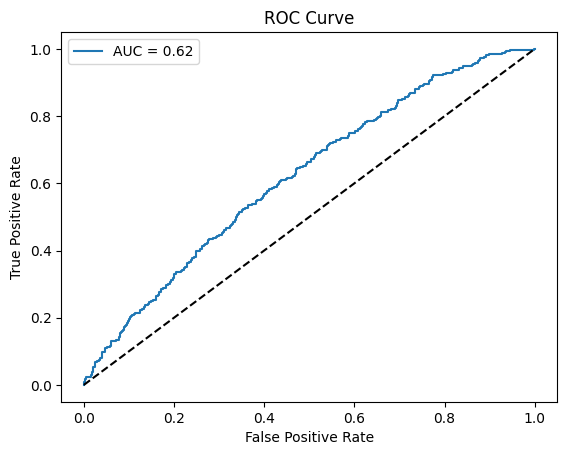

In [ ]:
# Use threshold 0.8
threshold = 0.8
y_pred_final = (y_pred_proba >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))

# ROC curve (to visualize)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

import matplotlib.pyplot as plt
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

# --- 1. Train & test probabilities ---
y_train_proba = best_model.predict_proba(x_train)[:, 1]
y_test_proba = best_model.predict_proba(x_test)[:, 1]

# --- 2. Apply threshold ---
threshold = 0.8
y_train_pred = (y_train_proba >= threshold).astype(int)
y_test_pred = (y_test_proba >= threshold).astype(int)

# --- 3. Accuracy comparison ---
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"🎯 Train Accuracy: {train_acc*100:.2f}%")
print(f"🧠 Test Accuracy: {test_acc*100:.2f}%")

🎯 Train Accuracy: 84.39%
🧠 Test Accuracy: 83.98%


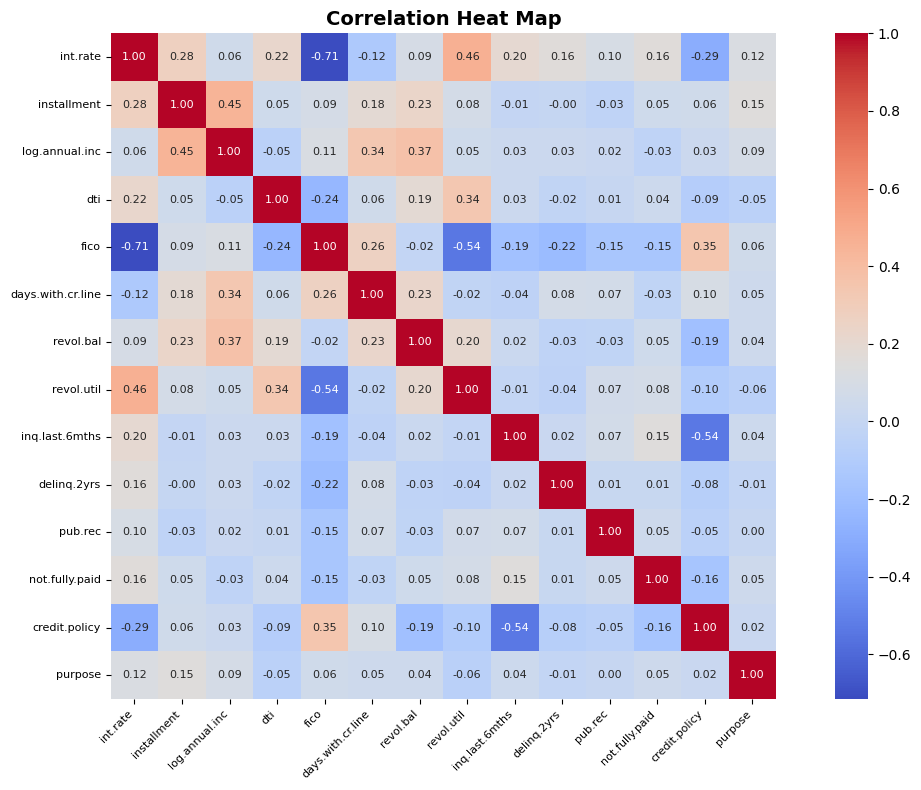

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Correlation Heatmap ---
plt.figure(figsize=(12, 8))  # ⬅️ Bigger figure for better spacing
corr = final_df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    cbar=True,
    square=True,
    annot_kws={"size": 8},  # smaller font for annotations
)

plt.title('Correlation Heat Map', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()  # avoids label cutoff
plt.show()



Confusion Matrix:
[[1603    6]
 [ 301    6]]


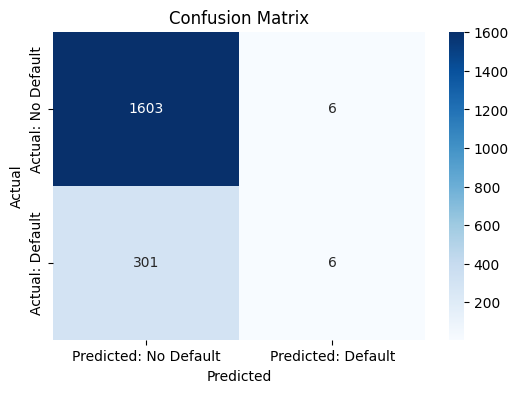

In [ ]:
# ---Plot Confusion Matrix ---
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Default', 'Predicted: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import joblib
joblib.dump(best_model, 'gradient_boost_model.pkl')
print("✅ Model saved as gradient_boost_model.pkl")

✅ Model saved as gradient_boost_model.pkl


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.6 MB/s eta 0:00:00


In [ ]:
import joblib

# Suppose these were your training features
feature_names = [
    'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico',
    'days.with.cr.line', 'revol.bal', 'revol.util',
    'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'purpose'
]

# Save both model and feature names
joblib.dump(best_model, 'gradient_boost_model.pkl')
joblib.dump(feature_names, 'model_features.pkl')

print("✅ Model and feature list saved successfully.")

✅ Model and feature list saved successfully.


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

# Load model and feature list
model = joblib.load('gradient_boost_model.pkl')
feature_names = joblib.load('model_features.pkl')

st.title("💳 Loan Default Prediction App")

# --- Collect inputs dynamically ---
user_input = {}

for feature in feature_names:
    if feature == 'purpose':
        user_input[feature] = st.selectbox(
            "Loan Purpose",
            ['credit_card', 'debt_consolidation', 'educational',
             'home_improvement', 'major_purchase', 'small_business', 'all_other']
        )
    else:
        user_input[feature] = st.number_input(f"{feature}", value=0.0)

# --- Manual encoding for 'purpose' ---
purpose_mapping = {
    'credit_card': 0,
    'debt_consolidation': 1,
    'educational': 2,
    'home_improvement': 3,
    'major_purchase': 4,
    'small_business': 5,
    'all_other': 6
}
user_input['purpose'] = purpose_mapping[user_input['purpose']]

# --- Convert to numpy array (ensure correct order) ---
X_input = np.array([[user_input[feat] for feat in feature_names]])

# --- Debug ---
st.write(f"✅ Input Shape: {X_input.shape}, Expected: {model.n_features_in_}")

# --- Predict ---
if st.button("Predict Loan Status"):
    proba = model.predict_proba(X_input)[0][1]
    threshold = 0.8
    prediction = 1 if proba >= threshold else 0

    st.write(f"**Model Confidence:** {proba:.2f}")
    if prediction == 1:
        st.error("❌ Loan likely **Not Fully Paid** (High Risk)")
    else:
        st.success("✅ Loan likely **Fully Paid** (Low Risk)")

Writing app.py


In [ ]:
!ngrok config add-authtoken 33khwj646Z4Qomcjsi4OnblbcJN_265woszgjARXoXXEdTHUT

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
import time
import subprocess

# Kill any previous tunnels
ngrok.kill()

# Start Streamlit app
process = subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"])

# Wait a few seconds to let Streamlit start
time.sleep(5)

# Create ngrok tunnel
public_url = ngrok.connect(8501)
print("🌍 Your Streamlit app is live here:", public_url)

🌍 Your Streamlit app is live here: NgrokTunnel: "https://nontangibly-unpoisonable-beulah.ngrok-free.dev" -> "http://localhost:8501"


/tmp/ipython-input-626401884.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_importances, palette='coolwarm')


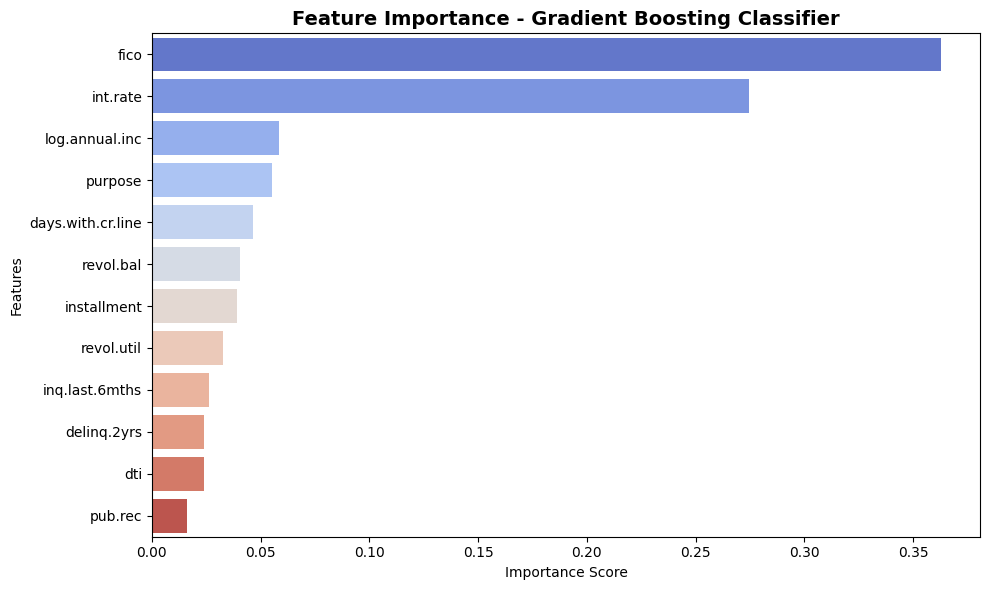

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Get feature importances ---
importances = best_model.feature_importances_

# Assuming x_train is a DataFrame
feature_names = x_train.columns

# --- 2. Create a DataFrame ---
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# --- 3. Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_importances, palette='coolwarm')
plt.title('Feature Importance - Gradient Boosting Classifier', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()
